# diag_stages_late — where does the 'late' stage begin in Llama-3.1-8B?

Uses the **logit lens** (nostalgebraist 2020; refined as the **tuned lens**, Belrose et al. 2023): apply the model's final norm + unembedding to *each* layer's residual stream to get a per-layer 'early readout', then measure the **KL divergence to the model's actual output distribution**, averaged over a small corpus.

**'Late' begins where that KL collapses** toward 0 (and the lens's top-1 token starts matching the final prediction) — that's the residual-sharpening / output stage you want to avoid when picking steering layers. ROME can't see this; the lens can.

Goal: get a layer L_late so you can steer in the window **~[16, L_late)** and skip the end stage.

In [1]:
import torch, numpy as np, os
from transformers import AutoModelForCausalLM, AutoTokenizer
os.makedirs('plots', exist_ok=True)
MODEL_ID='meta-llama/Meta-Llama-3.1-8B-Instruct'   # same Instruct model you steer
device=torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
dtype=torch.float16 if device.type!='cpu' else torch.float32
tok=AutoTokenizer.from_pretrained(MODEL_ID)
model=AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=dtype).to(device).eval()
NL=model.config.num_hidden_layers
print('layers:', NL)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

layers: 32


## Corpus (a small, diverse text sample to average the lens over)

In [2]:
CORPUS=[
 'The capital of France is Paris, a city on the Seine known for the Eiffel Tower.',
 'Water boils at one hundred degrees Celsius at sea level under normal pressure.',
 'She opened the old wooden door and stepped into the quiet, dusty library.',
 'In 1969, astronauts first walked on the surface of the Moon during Apollo 11.',
 'The recipe calls for two cups of flour, a pinch of salt, and three eggs.',
 'Photosynthesis converts sunlight, water, and carbon dioxide into glucose and oxygen.',
 'He felt nervous before the interview but answered every question with confidence.',
 'The stock market fell sharply on Monday before recovering later in the week.',
 'A group of musicians gathered in the square to play folk songs at sunset.',
 'The theorem states that the sum of the angles in a triangle equals 180 degrees.',
 'Rain tapped against the window as the train rolled north through the mountains.',
 'Researchers published a new study on how memory consolidates during deep sleep.',
]
print(len(CORPUS),'texts')

12 texts


## Logit-lens KL-to-final + top-1 agreement, per layer

In [3]:
norm = model.model.norm      # final RMSNorm
head = model.lm_head         # unembedding

@torch.no_grad()
def lens_profile(texts):
    KL=None; AG=None; n=0
    for t in texts:
        ids=tok(t, return_tensors='pt').to(device)
        out=model(**ids, output_hidden_states=True)
        final_logp=torch.log_softmax(out.logits[0].float(), -1)   # (seq, V) = the model's real output
        final_arg=final_logp.argmax(-1)
        hs=out.hidden_states                                       # tuple len NL+1 (0=embeddings)
        kl=torch.zeros(len(hs)); ag=torch.zeros(len(hs))
        for l in range(len(hs)):
            logp=torch.log_softmax(head(norm(hs[l][0])).float(), -1)   # logit lens at layer l
            kl[l]=(logp.exp()*(logp-final_logp)).sum(-1).mean().item() # KL(lens_l || final), avg over positions
            ag[l]=(logp.argmax(-1)==final_arg).float().mean().item()
            del logp
        KL=kl if KL is None else KL+kl; AG=ag if AG is None else AG+ag; n+=1
    return (KL/n).numpy(), (AG/n).numpy()

kl, ag = lens_profile(CORPUS)
print('computed lens profile over', len(CORPUS), 'texts; entries (incl. embedding@0):', len(kl))

computed lens profile over 12 texts; entries (incl. embedding@0): 33


## Find where 'late' begins

In [4]:
# index l in [0..NL]: l=0 is embeddings, l=NL is the final output (KL~0). Block b -> entry b+1.
# Late-onset heuristics:
kl_max=kl[1:].max()
late_kl   = next((l for l in range(1,len(kl)) if kl[l] < 0.10*kl_max), NL)   # KL fell below 10% of peak
late_ag50 = next((l for l in range(1,len(ag)) if ag[l] >= 0.50), NL)          # lens agrees with final on >50% tokens
late_ag80 = next((l for l in range(1,len(ag)) if ag[l] >= 0.80), NL)
print(f'KL drops <10% of peak at hidden-state index {late_kl}  (~block {late_kl-1})')
print(f'top-1 agreement >=50% at index {late_ag50}  (~block {late_ag50-1})')
print(f'top-1 agreement >=80% at index {late_ag80}  (~block {late_ag80-1})')
print(f'\n=> "late" stage ~ block {late_ag80-1}+ (residual sharpening). Suggested steering window: ~[16, {late_ag80-1}).')

KL drops <10% of peak at hidden-state index 32  (~block 31)
top-1 agreement >=50% at index 31  (~block 30)
top-1 agreement >=80% at index 32  (~block 31)

=> "late" stage ~ block 31+ (residual sharpening). Suggested steering window: ~[16, 31).


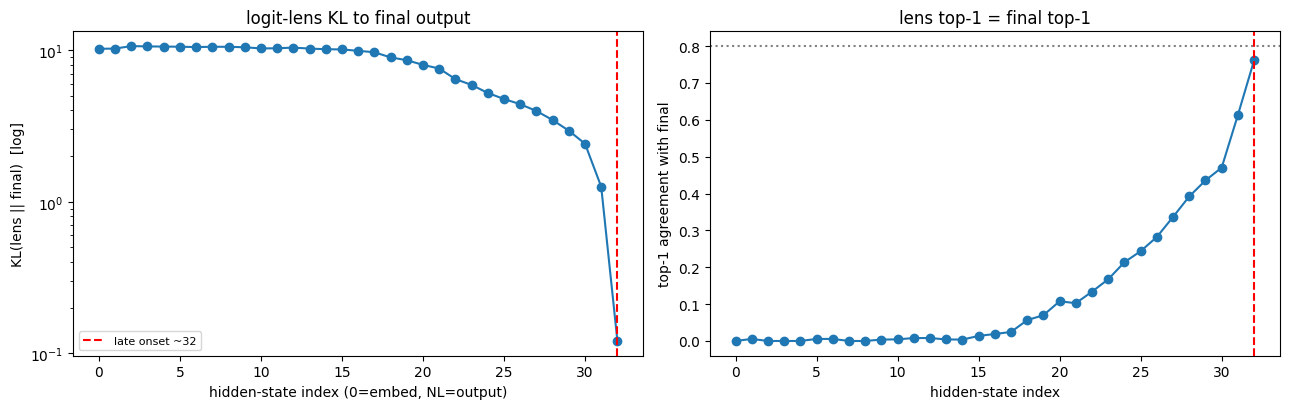

In [5]:
import matplotlib.pyplot as plt
x=np.arange(len(kl))
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
ax[0].plot(x,kl,'o-'); ax[0].set_yscale('log'); ax[0].set_xlabel('hidden-state index (0=embed, NL=output)')
ax[0].set_ylabel('KL(lens || final)  [log]'); ax[0].set_title('logit-lens KL to final output')
ax[0].axvline(late_ag80,color='r',ls='--',label=f'late onset ~{late_ag80}'); ax[0].legend(fontsize=8)
ax[1].plot(x,ag,'o-'); ax[1].axhline(0.8,color='grey',ls=':'); ax[1].axvline(late_ag80,color='r',ls='--')
ax[1].set_xlabel('hidden-state index'); ax[1].set_ylabel('top-1 agreement with final'); ax[1].set_title('lens top-1 = final top-1')
fig.tight_layout(); fig.savefig('plots/diag_stages_late.png',dpi=120); plt.show()

## Reading this
- **KL curve (left):** high/flat early (the readout is nothing like the output), then **drops sharply** — the knee marks where the model commits to its prediction. Layers past the knee are the **residual-sharpening / 'late'** stage.
- **Agreement (right):** rises to ~1; the crossing of ~0.8 is a clean 'late has begun' marker.
- **Use it:** steer in **~[16, late_onset)** — late enough that the *concept* (and the RFM last-token signal, which arrives ~mid layers per the ROME trace) is present, but before the model starts collapsing to output tokens.
- **Refinement:** the **tuned lens** (Belrose et al. 2023) learns an affine probe per layer and gives a sharper knee; a pretrained Llama-3.1-8B tuned lens can be loaded via the `tuned-lens` package if you want to double-check the logit-lens estimate. Logit lens is the no-dependency version used here.